# **Sumativa 6 (semana 10) // GRUPO N°11**

In [58]:
pip install pulp

In [2]:
# Importar librerias necesarias

import pulp
import numpy as np
import matplotlib.pyplot as plt

# **1. DEFINIR EL PROBLEMA**

In [80]:
# Definir el problema
prob = pulp.LpProblem("Maximizar Z", pulp.LpMaximize)

Se define el problema como uno de maximización, ya que el objetivo de la automotora es maximizar sus ingresos semanales por la venta de Sedanes y Pickups. Se utiliza pulp.LpProblem con el parámetro pulp.LpMaximize, en concordancia con el problema planteado en el enunciado.

# **2. VARIABLES DE DECISIÓN**

In [81]:
# Definir variables de decisión
X = pulp.LpVariable('X', lowBound=0, cat='Integer') # X >= 0
Y = pulp.LpVariable('Y', lowBound=0, cat='Integer') # Y >= 0

Las variables de decisión corresponden a X (cantidad de Sedanes a preparar) e Y (cantidad de Pickups a preparar). Ambas se definieron como variables enteras no negativas (lowBound=0, cat='Integer'), cumpliendo con las condiciones de no negatividad (
𝑋
,
𝑌
≥
0
X,Y≥0) e integralidad (
𝑋
,
𝑌
∈
𝑍
X,Y∈Z) exigidas en las instrucciones del trabajo, dado que no es posible preparar una fracción de vehículo.

# **3. FUNCIÓN OBJETIVO**

Se observa la estructura del dataset de la automotora, que incluye variables como fecha de venta, ciudad, marca, tipo de vehículo, precio de venta y kilometraje, entre otras, necesarias para calcular los parámetros del modelo.

In [61]:
# IMPORTAR LIBRERÍAS BÁSICAS:

# Librería para operaciones con arreglos
import numpy as np

# Librería estructura y manipulación de datos
import pandas as pd

# Apagar advertencias (opcional, se usa para no ensuciar el output)
import warnings
warnings.filterwarnings('ignore')

In [38]:
df = pd.read_excel("df_automotora_preprocesado_EA.xlsx")

In [8]:
df.head()

,ID,Fecha_Venta,Ciudad,Region,Marca,Tipo,Modelo,Color,Año_Fabricacion,Kilometraje,Antigüedad,Combustible,Transmision,Equipamiento,Precio_Venta,Metodo_Pago,Tipo_Garantia,Vencimiento_Garantia,Vigencia_Garantia
0,1,2020-01-01,Punta Arenas,Magallanes,Suzuki,SUV,Vitara,Plata,2023,20966.0,2.000000,Gasolina,Automática,Básico,15647640,leasing,1 año,2021-01-01,Vencida
1,2,2020-01-01,Coquimbo,Coquimbo,Peugeot,Hatchback,208,Rojo,2021,46558.0,9.998996,Diésel,Automática,Medio,6243702,credito,6 meses,2020-07-01,Vencida
2,4,2020-01-01,Talca,Maule,Nissan,Sedán,Versa,Verde,2016,97113.0,9.000000,Gasolina,Automática,Básico,5366021,credito,1 año,2021-01-01,Vencida
3,7,2020-01-01,Las Condes,Metropolitana,Suzuki,Sedán,Baleno,Blanco,2014,138689.0,6.000000,Gasolina,Automática,Medio,4352676,credito,Sin Garantía,2020-01-01,Vencida
4,8,2020-01-01,Maipú,Metropolitana,Toyota,Sedán,Corolla,Gris,2005,242320.0,15.000000,Gasolina,Manual,Básico,2093080,credito,Sin Garantía,2020-01-01,Vencida


Se observa la estructura del dataset de la automotora, que incluye variables como fecha de venta, ciudad, marca, tipo de vehículo, precio de venta y kilometraje, entre otras, necesarias para calcular los parámetros del modelo.

In [39]:
df['Tipo'].unique()

array(['SUV', 'Hatchback', 'Sedán', 'Pickup', 'Comercial'], dtype=object)

El dataset contiene distintos tipos de vehículos (Sedán, Pickup, SUV, Hatchback, Comercial), de los cuales se trabajará únicamente con Sedán y Pickup, según lo definido en el caso de estudio.

In [40]:
df.groupby(['Tipo'])['Precio_Venta'].mean() #Agrupar datos por media

,Precio_Venta
Tipo,
Comercial,5.760069e+06
Hatchback,4.597284e+06
Pickup,8.781963e+06
SUV,8.359396e+06
Sedán,5.181878e+06


Se calcula el precio promedio de venta agrupando por tipo de vehículo. Esta tabla agregada permite identificar que los vehículos tipo Pickup tienen un precio promedio superior al de los Sedán, información clave para construir la función objetivo.

In [82]:
promedio_venta_sedan = df[df['Tipo'] == 'Sedán']['Precio_Venta'].mean()
print(f"El promedio del precio de venta para vehículos Sedán es: {promedio_venta_sedan:,.2f}")

El promedio del precio de venta para vehículos Sedán es: 5,181,877.93


In [83]:
promedio_venta_pickup = df[df['Tipo'] == 'Pickup']['Precio_Venta'].mean()
print(f"El promedio del precio de venta para vehículos Pickup es: {promedio_venta_pickup:,.2f}")

El promedio del precio de venta para vehículos Pickup es: 8,781,963.19


El precio promedio del Sedán (
𝑃
𝑠
P
s
)
es de $5.181.877, mientras que el del Pickup

(
𝑃
𝑝
P
p
) es de $8.781.963. Estos valores representan el ingreso unitario por cada vehículo vendido y serán los coeficientes de la función objetivo.

In [84]:
# Definir la función objetivo
prob +=  5181877.93*X + 8781963.19*Y, "Z"

Se define la función objetivo del modelo como la suma de los ingresos generados por ambos tipos de vehículos, multiplicando la cantidad a producir de cada uno por su respectivo precio promedio de venta. De esta forma, la función objetivo representa el ingreso total semanal que la automotora busca maximizar. Cabe destacar que este modelo no considera costos de producción, ya que el enunciado establece explícitamente que el objetivo es maximizar los ingresos totales.

# **4. RESTRICCIONES**

2X+5Y<=H

X+Y<=D

In [85]:
# Asegurarse de que 'Fecha_Venta' sea tipo datetime
df['Fecha_Venta'] = pd.to_datetime(df['Fecha_Venta'])

# Filtrar por vehículos 'Sedán'
df_sedan = df[df['Tipo'] == 'Sedán']

# Agrupar por semana y contar el número de ventas (demanda semanal)
demanda_semanal = df_sedan.groupby(df_sedan['Fecha_Venta'].dt.to_period('W')).size().reset_index(name='Cantidad_Ventas')

# Calcular el promedio de la demanda semanal
promedio_demanda_semanal_sedan = demanda_semanal['Cantidad_Ventas'].mean()

print(f"La demanda promedio semanal para vehículos Sedán es: {promedio_demanda_semanal_sedan:,.2f} unidades")

La demanda promedio semanal para vehículos Sedán es: 72.80 unidades


Para estimar la demanda semanal de Sedanes se agruparon las ventas históricas por semana, utilizando Fecha_Venta.dt.to_period('W') para asignar cada venta a su semana calendario, .size() para contar el número de ventas por semana, y finalmente .mean() para obtener el promedio de ventas semanales (metodología estándar de agregación temporal con pandas, se detalla en la bibliografía). El resultado obtenido es de 72 unidades semanales en promedio.

In [86]:
# Asegurarse de que 'Fecha_Venta' sea tipo datetime (ya se hizo previamente, pero se mantiene por robustez)
df['Fecha_Venta'] = pd.to_datetime(df['Fecha_Venta'])

# Filtrar por vehículos 'Pickup'
df_pickup = df[df['Tipo'] == 'Pickup']

# Agrupar por semana y contar el número de ventas (demanda semanal)
demanda_semanal_pickup = df_pickup.groupby(df_pickup['Fecha_Venta'].dt.to_period('W')).size().reset_index(name='Cantidad_Ventas')

# Calcular el promedio de la demanda semanal
promedio_demanda_semanal_pickup = demanda_semanal_pickup['Cantidad_Ventas'].mean()

print(f"La demanda promedio semanal para vehículos Pickup es: {promedio_demanda_semanal_pickup:,.2f} unidades")

La demanda promedio semanal para vehículos Pickup es: 10.28 unidades


Se aplica el mismo procedimiento para los vehículos Pickup, obteniendo una demanda promedio semanal de 10 unidades. Se observa que la demanda de Sedanes es considerablemente mayor a la de Pickups, lo que impactará directamente en la restricción de almacenamiento.

In [87]:
# Definir restricciones
prob += 2*X + 5*Y <= 200, "Restricción 1(Tiempo)"
prob += X + Y <= 83 ,  "Restricción 2(Almacenamiento)"

Se definen las dos restricciones del modelo. La primera corresponde a la disponibilidad de tiempo técnico, ya que cada Sedán requiere 2 horas de preparación y cada Pickup 5 horas, contando el centro con un total de 200 horas semanales disponibles para realizar estas labores. La segunda restricción corresponde a la capacidad de almacenamiento del centro, la cual se determina a partir de la demanda semanal proyectada de cada tipo de vehículo, calculada como la suma de las demandas semanales promedio históricas de Sedanes y Pickups, obtenidas previamente a partir del dataset.

# **5. OPTIMIZACIÓN**

In [88]:
# Resolver el problema
prob.solve()

# Imprimir el estado del problema (si se encontró una solución óptima)
print("Estado:", pulp.LpStatus[prob.status])

# Obtener el óptimo determinístico:

# 1. valores óptimos de las variables de decisión
opt_X = pulp.value(X)
opt_Y = pulp.value(Y)

# 2. valor óptimo de la función objetivo
opt_Z = pulp.value(prob.objective)

print(f"Óptimo Determinístico: X = {opt_X}, Y = {opt_Y}, Z = {opt_Z}")

Estado: Optimal
Óptimo Determinístico: X = 72.0, Y = 11.0, Z = 469696806.04999995


Se encontró una solución óptima, lo que confirma que existe una combinación factible de producción que maximiza los ingresos dadas las restricciones establecidas. A partir de este resultado se obtiene la cantidad óptima de Sedanes y Pickups que la automotora debería preparar semanalmente, así como el ingreso máximo esperado asociado a dicha combinación. Esto indica que, considerando las limitaciones actuales de tiempo técnico y capacidad de almacenamiento, esta distribución de producción representa la mejor decisión posible para maximizar los ingresos de la empresa.

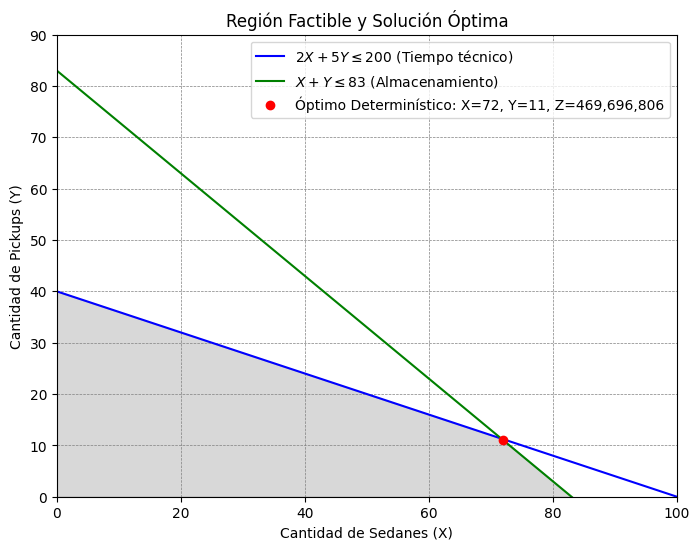

In [90]:
# Definir las restricciones para la gráfica:
x_vals = np.linspace(0, 100, 500)  # Ajustar el rango de valores para X

y1_vals = (200 - 2*x_vals) / 5   # De la restricción 2X + 5Y <= 200 (tiempo técnico, H)
y2_vals = 83 - x_vals             # De la restricción X + Y <= 83 (almacenamiento, D)

# Crear el gráfico
plt.figure(figsize=(8, 6))

# Graficar las restricciones (líneas)
plt.plot(x_vals, y1_vals, label=r'$2X + 5Y \leq 200$ (Tiempo técnico)', color='blue')
plt.plot(x_vals, y2_vals, label=r'$X + Y \leq 83$ (Almacenamiento)', color='green')

# Región factible sombreada
plt.fill_between(x_vals, 0, np.minimum(y1_vals, y2_vals),
                  where=(np.minimum(y1_vals, y2_vals) >= 0),
                  color='grey', alpha=0.3)

# Marcar el punto óptimo
plt.plot(opt_X, opt_Y, 'ro',
         label=f'Óptimo Determinístico: X={opt_X:.0f}, Y={opt_Y:.0f}, Z={opt_Z:,.0f}')

# Configuraciones del gráfico
plt.xlim((0, 100))   # Ajustado a la escala real del problema
plt.ylim((0, 90))
plt.xlabel('Cantidad de Sedanes (X)')
plt.ylabel('Cantidad de Pickups (Y)')
plt.title('Región Factible y Solución Óptima')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


El gráfico muestra la región factible (área gris) delimitada por ambas restricciones, junto con el punto óptimo determinístico (rojo). Se observa que el punto óptimo se ubica en un vértice de la región factible, lo cual es consistente con la teoría de programación lineal: la solución óptima de un problema de maximización siempre se encuentra en un vértice del polígono factible.

# **6. ANÁLISIS DE SENSIBILIDAD**

In [91]:
rob = pulp.LpProblem("Maximizar Z Robusto", pulp.LpMaximize)

Xr = pulp.LpVariable('X', lowBound=0)
Yr = pulp.LpVariable('Y', lowBound=0)

rob += promedio_venta_sedan*0.90*Xr + promedio_venta_pickup*0.90*Yr, "Z_rob"

# Aplicamos directamente el 90% (reducción del 10%)
rob += 2*Xr + 5*Yr <= 200 * 0.90, "Restriccion 1 -10%"
rob += Xr + Yr <= 83 * 0.90, "Restriccion 2 -10%"

rob.solve()

rob_X = pulp.value(Xr)
rob_Y = pulp.value(Yr)
rob_Z = pulp.value(rob.objective)

print(f"X = {rob_X}, Y = {rob_Y}, Z = {rob_Z}")

X = 64.5, Y = 10.2, Z = 381426435.9923831


Al reducir en un 10% los parámetros H, D,
𝑃
𝑠
P
s
y
𝑃
𝑝
P
p
, simulando un escenario más conservador, se obtiene una nueva solución óptima bajo condiciones de menor disponibilidad  y precios de venta más bajos. Esta solución robusta permite evaluar cómo se ajusta la producción óptima de Sedanes y Pickups, así como el ingreso máximo alcanzable, cuando la capacidad de preparación de vehículos, la demanda proyectada y los precios de mercado son menos favorables que en el escenario original.


In [92]:
# Calcular el porcentaje de variación de la solución robusta respecto al óptimo determinístico
variacion = ((rob_Z - opt_Z) / opt_Z) * 100
print(f"Porcentaje de Variación de la Solución Robusta respecto al Óptimo Determinístico: {variacion:.2f}%")

Porcentaje de Variación de la Solución Robusta respecto al Óptimo Determinístico: -18.79%


La variación de los ingresos máximos de la solución robusta respecto al óptimo determinístico es de -18.79%. Esta reducción es esperable, ya que al disminuir simultáneamente la capacidad de producción, la demanda y los precios, el ingreso máximo alcanzable necesariamente disminuye.

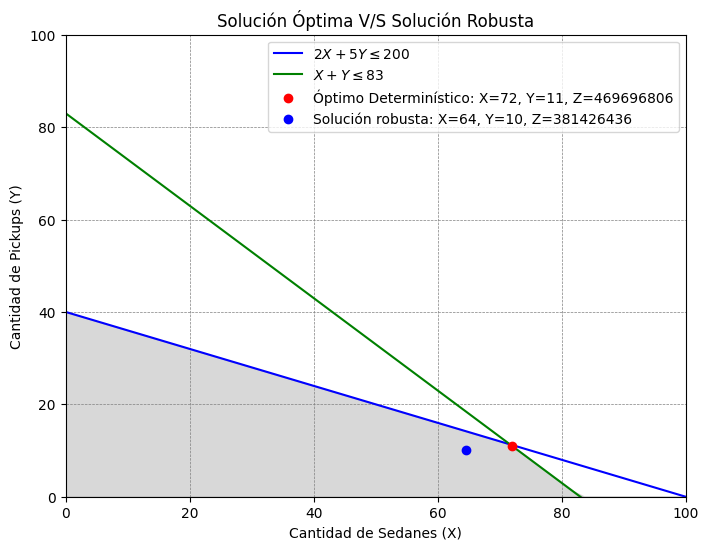

In [93]:
# Definir las restricciones para la gráfica
x_vals = np.linspace(0, 100)  # Ajustar el rango de valores para X
y1_vals = (200 - 2*x_vals) / 5  # De la restricción 2X + 5Y <= 200 (tiempo técnico)
y2_vals = 83 - x_vals  # De la restricción X + Y <= 83 (almacenamiento)

# Crear el gráfico
plt.figure(figsize=(8, 6))

# Graficar las restricciones
plt.plot(x_vals, y1_vals, label=r'$2X + 5Y \leq 200$', color='blue')  # Restricción de tiempo técnico
plt.plot(x_vals, y2_vals, label=r'$X + Y \leq 83$', color='green')  # Restricción de almacenamiento

# Región factible sombreada
plt.fill_between(x_vals, np.maximum(0, np.minimum(y1_vals, y2_vals)), color='grey', alpha=0.3)

# Marcar el punto óptimo
plt.plot(opt_X, opt_Y, 'ro', label=f'Óptimo Determinístico: X={opt_X:.0f}, Y={opt_Y:.0f}, Z={opt_Z:.0f}')

# Marcar el punto de la solución robusta (peor de los casos)
plt.plot(rob_X, rob_Y, 'bo', label=f'Solución robusta: X={rob_X:.0f}, Y={rob_Y:.0f}, Z={rob_Z:.0f}')

# Configuraciones del gráfico
plt.xlim((0, 100))  # Limitar el rango de valores de X para mostrar las restricciones
plt.ylim((0, 100))  # Limitar el rango de valores de Y para mostrar las restricciones
plt.xlabel('Cantidad de Sedanes (X)')
plt.ylabel('Cantidad de Pickups (Y)')
plt.title('Solución Óptima V/S Solución Robusta')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

El gráfico compara ambas soluciones, se observa que la región factible robusta (definida por restricciones más estrictas) es un subconjunto de la región determinística, y que el punto óptimo robusto (azul) se desplaza hacia una zona de menor producción respecto al óptimo original (rojo), reflejando una postura más realista ante la incertidumbre o inpondeables en los parámetros del modelo.

# **CONCLUSIÓN**

El modelo de programación lineal permitió determinar que la automotora debe priorizar la preparación de Sedanes por sobre Pickups para maximizar sus ingresos semanales, dado el menor consumo de horas técnicas por unidad. Sin embargo, al incorporar un escenario más conservador (robusto)(reducción del 10% en los parámetros clave), los ingresos máximos disminuyen, evidenciando la sensibilidad del modelo ante variaciones en la disponibilidad de recursos y en las condiciones de mercado. Esto le indicaría a la automotora debería planificar su producción considerando un margen de holgura, y no basarse exclusivamente en el escenario más optimista, para asegurar la sostenibilidad de sus ingresos ante inpoderables en la demanda, los precios o la capacidad de preparación de vehículos.

---
---
# **BIBLIOGRAFÍA**

The pandas Development Team. (2024). How to handle time series data with ease. pandas documentation. https://pandas.pydata.org/docs/getting_started/intro_tutorials/09_timeseries.html **(PROFESORA ESTO LO BUSQUÉ POR INTERNET PERO LO UTILICÉ PARA VER LOS PROMEDIOS SEMANALES DE VENTAS)**

NumPy Developers. (s.f.). NumPy documentation. NumPy. https://numpy.org/devdocs/user/index.html#user

The Matplotlib Development Team. (s.f.). Matplotlib documentation. Matplotlib. https://matplotlib.org/stable/users/index.html

COIN-OR Foundation. (s.f.). PuLP documentation. GitHub Pages. https://coin-or.github.io/pulp/guides/index.html
